CÉLULA 0: Extração de Features

In [57]:
# ============================================================
# CÉLULA 0 CORRIGIDA – Extração de Features com Re‑referência
#                    e NORMALIZAÇÃO DE AMPLITUDE POR SUJEITO
# ============================================================
import re
import traceback
from pathlib import Path
import warnings
import mne
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

PASTA_AD = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer"
PASTA_HC = r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc"
OUT_CSV_FULL = "eeg_features_brainlat_FULL_normalizado.csv"
OUT_FAILS = "eeg_features_brainlat_falhas_normalizado.csv"

BANDS = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 30),
    "Gamma": (30, 45),
}
FMIN = 0.5
FMAX = 45

def extrair_subject_id(arq_path: Path) -> str:
    m = re.search(r"(sub-\d+)", arq_path.stem, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m = re.search(r"sub[-_]?(\d+)", arq_path.stem, flags=re.IGNORECASE)
    if m:
        return f"sub-{m.group(1)}"
    return arq_path.stem

def inferir_pais(arq_path: Path) -> str:
    parts = {p.upper() for p in arq_path.parts}
    if "AR" in parts:
        return "Argentina"
    if "CL" in parts:
        return "Chile"
    return "Outro"

def carregar_raw_seguro(arq_path: Path):
    try:
        return mne.io.read_raw_eeglab(str(arq_path), preload=True, verbose=False)
    except Exception as e:
        msg = str(e).lower()
        if ("fdt" in msg) or ("not found" in msg):
            fdt_exato = arq_path.with_suffix(".fdt")
            if fdt_exato.exists():
                from tempfile import TemporaryDirectory
                with TemporaryDirectory() as tmp:
                    tmp_p = Path(tmp)
                    set_tmp = tmp_p / arq_path.name
                    fdt_tmp = tmp_p / fdt_exato.name
                    set_tmp.write_bytes(arq_path.read_bytes())
                    fdt_tmp.write_bytes(fdt_exato.read_bytes())
                    return mne.io.read_raw_eeglab(str(set_tmp), preload=True, verbose=False)
        raise e

def extrair_metricas_eeg(data, sfreq):
    """
    data: array (canais, amostras) já normalizado (RMS = 1 globalmente)
    """
    from mne.time_frequency import psd_array_welch
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"Esperado array 2D, recebido shape={data.shape}")
    n_fft = min(512, data.shape[-1])
    psds, freqs = psd_array_welch(
        data, sfreq=sfreq, fmin=FMIN, fmax=FMAX,
        n_fft=n_fft, verbose=False
    )
    psd_media = np.mean(psds, axis=0)
    metodo_area = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    pots = {}
    for banda, (fmin, fmax) in BANDS.items():
        idx = (freqs >= fmin) & (freqs < fmax)
        if np.sum(idx) >= 2:
            pots[banda] = float(metodo_area(psd_media[idx], freqs[idx]))
        else:
            pots[banda] = 0.0
            if banda == "Delta":
                print(f"  ⚠ Atenção: poucos pontos na banda Delta (freqs disponíveis: {freqs})")

    total = sum(pots.values()) + 1e-12
    f = {
        "Rel_Delta_mean": pots["Delta"] / total,
        "Rel_Theta_mean": pots["Theta"] / total,
        "Rel_Alpha_mean": pots["Alpha"] / total,
        "Rel_Beta_mean":  pots["Beta"] / total,
        "Rel_Gamma_mean": pots["Gamma"] / total,
    }
    f["Razao_Theta_Alpha"] = f["Rel_Theta_mean"] / (f["Rel_Alpha_mean"] + 1e-12)
    f["Razao_Theta_Beta"]  = f["Rel_Theta_mean"] / (f["Rel_Beta_mean"] + 1e-12)

    # (opcional: se quiser manter entropia, descomente; mas por ora removida)
    psd_norm = psd_media / (np.sum(psd_media) + 1e-12)
    f["Spectral_Entropy"] = float(-np.sum(psd_norm * np.log2(psd_norm + 1e-12)))
    return f

# ========== Extração principal ==========
dados_finais = []
falhas = []

for grupo, pasta in [("AD", PASTA_AD), ("HC", PASTA_HC)]:
    arquivos = list(Path(pasta).rglob("*.set"))
    print(f"\n📂 {grupo}: {len(arquivos)} arquivos.")
    for arq in arquivos:
        try:
            sujeito_id = extrair_subject_id(arq)
            pais = inferir_pais(arq)
            raw = carregar_raw_seguro(arq)

            # --- 1. Re‑referenciação para a média ---
            raw.set_eeg_reference('average', projection=False)

            # --- 2. Filtro passa‑faixa (0.5 - 45 Hz) ---
            raw.filter(0.5, 45, fir_design='firwin', verbose=False)

            # --- 3. Selecionar apenas canais EEG ---
            raw.pick_types(eeg=True, eog=False, ecg=False, stim=False, emg=False, misc=False)

            # --- 4. Criar épocas de 4 segundos ---
            epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
            if len(epochs) == 0:
                raise RuntimeError("Nenhuma época gerada.")

            data = epochs.get_data()   # (n_epochs, n_channels, n_times)
            sfreq = float(raw.info["sfreq"])

            # --- 5. NORMALIZAÇÃO DE AMPLITUDE POR SUJEITO (global RMS) ---
            # Calcula o RMS de todas as épocas do sujeito e divide cada época por esse valor.
            all_data = data.reshape(-1, data.shape[-1])  # (n_epochs * n_channels, n_times)
            global_rms = np.sqrt(np.mean(all_data**2))
            if global_rms < 1e-12:
                global_rms = 1.0   # segurança
            scale = 1.0 / global_rms
            data_normalized = data * scale   # agora cada época tem RMS ~1 (global)

            # --- 6. Extrair features época a época ---
            for i, epoca in enumerate(data_normalized):
                feat = extrair_metricas_eeg(epoca, sfreq)
                feat.update({
                    "subject_id": sujeito_id,
                    "label": grupo,
                    "Pais": pais,
                    "epoch_id": i,
                    "source_file": arq.name,
                })
                dados_finais.append(feat)

            print(f"  ✅ {sujeito_id} ({len(data)} épocas) | RMS global = {global_rms:.6f} -> escala = {scale:.2f}")
        except Exception as e:
            falhas.append({
                "grupo": grupo,
                "arquivo": arq.name,
                "caminho": str(arq),
                "erro": str(e),
                "traceback": traceback.format_exc(),
            })
            print(f"  ❌ {arq.name} → {e}")

# ========== Salvar DataFrames ==========
df_full = pd.DataFrame(dados_finais)
df_falhas = pd.DataFrame(falhas)

if df_full.empty:
    raise RuntimeError("Nenhuma época extraída.")

cols_meta = ["subject_id", "label", "Pais", "epoch_id", "source_file"]
cols_feat = [c for c in df_full.columns if c not in cols_meta]
df_full = df_full[cols_meta + cols_feat]

df_full.to_csv(OUT_CSV_FULL, index=False, encoding="utf-8-sig")
df_falhas.to_csv(OUT_FAILS, index=False, encoding="utf-8-sig")

print(f"\n✅ Salvo: {OUT_CSV_FULL}")
print(f"✅ Salvo: {OUT_FAILS}")
print("\n" + "="*50)
print("  RESUMO DA EXTRAÇÃO (NORMALIZADA POR SUJEITO)")
print("="*50)
print(f"  Sujeitos totais : {df_full['subject_id'].nunique()}")
print(f"  Sujeitos AD     : {df_full[df_full['label'] == 'AD']['subject_id'].nunique()}")
print(f"  Sujeitos HC     : {df_full[df_full['label'] == 'HC']['subject_id'].nunique()}")
print(f"  Épocas totais   : {len(df_full):,}")
print(f"  Falhas          : {len(df_falhas)}")
print("="*50)


📂 AD: 35 arquivos.
  ✅ sub-30001 (78 épocas) | RMS global = 0.000007 -> escala = 138950.43
  ✅ sub-30002 (80 épocas) | RMS global = 0.000009 -> escala = 115849.62


KeyboardInterrupt: 

CÉLULA 1 — Importações e Configurações

In [58]:
# ============================================================
# CÉLULA 1 — INSTALAÇÕES E IMPORTAÇÕES
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.utils import shuffle

try:
    from neuroCombat import neuroCombat
    COMBAT_AVAILABLE = True
except ImportError:
    COMBAT_AVAILABLE = False

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print("✅ Ambiente configurado metodologicamente.")

✅ Ambiente configurado metodologicamente.


CÉLULA 2 — Funções de Pré-Processamento Seguras (Isolamento)

In [59]:
# ============================================================
# CÉLULA 2 — ISOLAMENTO DE TRANSFORMAÇÕES
# Justificativa: Para aplicar ComBat ou Scaler de maneira correta,
# eles devem ser ajustados SOMENTE no Train e aplicados ao Test.
# ============================================================

def aplicar_params_combat(X_te, combat_out):
    """
    Função mock para aplicar parâmetros do ComBat ao Teste.
    NOTA: Como o pacote padrão 'neuroCombat' em Python não possui
    um método .transform(), em produção recomenda-se usar pacotes como 
    'neuroCombat-sklearn' ou re-implementar a normalização por batch.
    Para este pipeline metodológico, garantimos que a transformação não olhe o teste.
    """
    return X_te.copy()

def aplicar_standard_scaler(X_tr, X_te, cols):
    """
    Aplica Z-score isolado: Estatísticas do treino ajustam o teste.
    Evita a dupla normalização e garante alinhamento geométrico para o SVM.
    """
    scaler = StandardScaler()
    X_tr_scaled = X_tr.copy()
    X_te_scaled = X_te.copy()
    
    X_tr_scaled[cols] = scaler.fit_transform(X_tr[cols])
    X_te_scaled[cols] = scaler.transform(X_te[cols])
    
    return X_tr_scaled, X_te_scaled

CÉLULA 3 — O Motor Central: LOSO Correto e Blindado

In [64]:
# ============================================================
# CÉLULA 7 — LOSO CORRETO (sem leakage de pré-processamento)
#
# FEATURE_COLS: Mobility e Complexity REMOVIDAS.
# Diagnóstico: ambas derivadas de np.mean(data, axis=0) no
# script de extração. Arquivos HC pré-processados com referência
# média → mean(canais) ≈ 0 por construção algébrica → Mobility
# colapsa para ~2.7e-7 e Complexity para ~1.732 em TODOS os
# sujeitos HC (std=0.013 em 32 sujeitos — impossível como sinal
# biológico). 6 sujeitos AD com referência diferente têm
# Complexity < 1.0 e Mobility > 0.003, criando separação
# perfeita por artefato de referência, não por Alzheimer.
# Features espectrais (Rel_*, Razao_*, Spectral_Entropy)
# são invariantes à referência → biologicamente defensáveis.
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import numpy as np
import pandas as pd

# ── Features biologicamente válidas ─────────────────────────
# Removidas:
#   Rel_Delta_mean → std = 0.0 (coluna morta no CSV)
#   Mobility       → artefato de referência de eletrodo
#   Complexity     → derivada de Mobility, mesmo artefato
#   Soma_Check     → variável de diagnóstico, não feature EEG
FEATURE_COLS = [
    'Rel_Theta_mean',
    'Rel_Alpha_mean',
    'Rel_Beta_mean',
    'Rel_Gamma_mean',
    'Razao_Theta_Alpha',
    'Razao_Theta_Beta',
    'Spectral_Entropy', 
]


def aplicar_standard_scaler(X_tr, X_te, cols):
    """Fit APENAS no treino, transform em ambos. Sem dupla normalização."""
    scaler   = StandardScaler()
    X_tr_out = X_tr.copy()
    X_te_out = X_te.copy()
    X_tr_out[cols] = scaler.fit_transform(X_tr[cols])
    X_te_out[cols] = scaler.transform(X_te[cols])
    return X_tr_out, X_te_out


def loso_correto(X_df, y_arr, groups_arr, modelo_base,
                 feature_cols=FEATURE_COLS, verbose=True):
    """
    Leave-One-Subject-Out sem vazamento de pré-processamento.

    Parâmetros
    ----------
    X_df         : pd.DataFrame — épocas × features
    y_arr        : array-like   — rótulo binário por época (0=HC, 1=AD)
    groups_arr   : array-like   — subject_id por época
    modelo_base  : estimador sklearn — clonado a cada fold
    feature_cols : lista de features usadas no treino/predição
    verbose      : bool — imprime progresso por fold

    Retorna
    -------
    pd.DataFrame com colunas [subject_id, real, proba, n_epocas]
    ou None se nenhum fold for válido.
    """

    # ── Validações iniciais ──────────────────────────────────
    X_df       = X_df.reset_index(drop=True)
    y_arr      = np.asarray(y_arr).ravel()
    groups_arr = np.asarray(groups_arr).ravel()

    if not (len(X_df) == len(y_arr) == len(groups_arr)):
        raise ValueError(
            f"Tamanhos incompatíveis: X={len(X_df)}, "
            f"y={len(y_arr)}, groups={len(groups_arr)}"
        )

    cols_ausentes = [c for c in feature_cols if c not in X_df.columns]
    if cols_ausentes:
        raise ValueError(f"Features ausentes no DataFrame: {cols_ausentes}")

    # ── Auditoria de variância antes de treinar ───────────────
    std_zero = [c for c in feature_cols if X_df[c].std() < 1e-8]
    if std_zero:
        raise ValueError(
            f"Features com variância zero detectadas (artefato): {std_zero}\n"
            f"Remova-as de FEATURE_COLS antes de continuar."
        )

    logo       = LeaveOneGroupOut()
    preds      = []
    skipped    = []
    n_subjects = len(np.unique(groups_arr))

    if verbose:
        print(f"   Iniciando {n_subjects} folds LOSO...\n")

    # ── Loop principal ───────────────────────────────────────
    for fold_i, (train_idx, test_idx) in enumerate(
            logo.split(X_df, y_arr, groups=groups_arr)):

        subj_id = groups_arr[test_idx][0]

        X_tr_raw = X_df.iloc[train_idx]
        X_te_raw = X_df.iloc[test_idx]
        y_tr     = y_arr[train_idx]
        y_te     = y_arr[test_idx]

        # Fold inválido: treino sem as duas classes
        if len(np.unique(y_tr)) < 2:
            skipped.append(subj_id)
            if verbose:
                print(f"  ⚠  Fold {fold_i+1:02d} [{subj_id}] "
                      f"ignorado — treino com classe única")
            continue

        # [1] Normalização: fit APENAS no treino
        X_tr_sc, X_te_sc = aplicar_standard_scaler(
            X_tr_raw, X_te_raw, feature_cols
        )

        # [2] Modelo clonado (estado virgem a cada fold)
        modelo = clone(modelo_base)
        modelo.fit(X_tr_sc[feature_cols], y_tr)

        # [3] Predição por época
        proba_epocas = modelo.predict_proba(
            X_te_sc[feature_cols]
        )[:, 1]

        # [4] Agregação por sujeito (média das épocas)
        proba_sujeito = float(np.mean(proba_epocas))
        label_sujeito = int(y_te[0])

        preds.append({
            "subject_id" : subj_id,
            "real"       : label_sujeito,
            "proba"      : proba_sujeito,
            "n_epocas"   : len(proba_epocas),
        })

        if verbose:
            acerto = "✓" if int(proba_sujeito >= 0.5) == label_sujeito else "✗"
            print(f"  {acerto}  [{fold_i+1:02d}/{n_subjects}] "
                  f"{subj_id:<18} | "
                  f"real={'AD' if label_sujeito else 'HC'} | "
                  f"proba={proba_sujeito:.3f} | "
                  f"n_épocas={len(proba_epocas)}")

    # ── Resultado final ──────────────────────────────────────
    if len(preds) == 0:
        print("  ⚠  Nenhuma predição gerada — todos os folds foram ignorados.")
        return None

    if skipped and verbose:
        print(f"\n  ⚠  {len(skipped)} fold(s) ignorado(s): {skipped}")

    df_preds = pd.DataFrame(preds)

    pred_bin = (df_preds["proba"] >= 0.5).astype(int)
    df_preds.attrs["auc"]  = roc_auc_score(df_preds["real"], df_preds["proba"])
    df_preds.attrs["sens"] = recall_score(df_preds["real"], pred_bin,
                                          pos_label=1, zero_division=0)
    df_preds.attrs["spec"] = recall_score(df_preds["real"], pred_bin,
                                          pos_label=0, zero_division=0)
    df_preds.attrs["f1"]   = f1_score(df_preds["real"], pred_bin,
                                      zero_division=0)

    return df_preds  # ← FORA do loop


print("✅ loso_correto() e aplicar_standard_scaler() definidas.")
print(f"   FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print()
print("⚠️  Mobility e Complexity excluídas — artefato de referência de eletrodo.")
print("   Hjorth correto requer cálculo POR CANAL com referência homogênea.")
print("   Ver: Célula 1 → extrair_metricas_eeg() para correção futura.")

✅ loso_correto() e aplicar_standard_scaler() definidas.
   FEATURE_COLS (7): ['Rel_Theta_mean', 'Rel_Alpha_mean', 'Rel_Beta_mean', 'Rel_Gamma_mean', 'Razao_Theta_Alpha', 'Razao_Theta_Beta', 'Spectral_Entropy']

⚠️  Mobility e Complexity excluídas — artefato de referência de eletrodo.
   Hjorth correto requer cálculo POR CANAL com referência homogênea.
   Ver: Célula 1 → extrair_metricas_eeg() para correção futura.


CÉLULA 4 — Definição dos Modelos (Saneados)

In [65]:
# ============================================================
# CÉLULA 4 — MODELOS SANEADOS
# Justificativa: O RobustScaler extra foi removido, pois o Z-score
# já é feito no passo 2 do LOSO correto.
# O SVM_Linear agora é calibrado com CV explícito ou usamos SGD (Huber loss).
# ============================================================

modelos_corrigidos = {
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1),
    
    # Calibração explícita e CV seguro
    'SVM_Calibrado': CalibratedClassifierCV(
        estimator=SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=SEED),
        cv=5
    ),
    
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, 
                             eval_metric='logloss', random_state=SEED, n_jobs=-1)
}

In [66]:
# Célula 10 — carregamento do CSV
import pandas as pd

df_audit = pd.read_csv("eeg_features_brainlat_FULL_normalizado.csv")

# NÃO redefine FEATURE_COLS aqui — já definido na Célula 7
# Rel_Delta_mean tem std=0.0 no dataset inteiro e foi excluída

required_cols = ["subject_id", "label"] + FEATURE_COLS
missing_cols  = [c for c in required_cols if c not in df_audit.columns]
if missing_cols:
    raise ValueError(f"Colunas ausentes no CSV: {missing_cols}")

print(f"✅ Dados carregados: {df_audit.shape}")
print(f"✅ Sujeitos únicos : {df_audit['subject_id'].nunique()}")
print(f"✅ Classes         : {df_audit['label'].value_counts().to_dict()}")
display(df_audit[required_cols].head())
display(df_audit[required_cols].head())

✅ Dados carregados: (7425, 13)
✅ Sujeitos únicos : 67
✅ Classes         : {'AD': 3716, 'HC': 3709}


,subject_id,label,Rel_Theta_mean,Rel_Alpha_mean,Rel_Beta_mean,Rel_Gamma_mean,Razao_Theta_Alpha,Razao_Theta_Beta,Spectral_Entropy
0,sub-30001,AD,0.149506,0.376055,0.197166,0.166569,0.397564,0.758275,4.793391
1,sub-30001,AD,0.095522,0.380232,0.254774,0.183788,0.251222,0.374929,4.915253
2,sub-30001,AD,0.214416,0.288051,0.266376,0.137222,0.744368,0.804936,4.914134
3,sub-30001,AD,0.213063,0.345595,0.241357,0.113756,0.616509,0.882770,4.616777
4,sub-30001,AD,0.206893,0.368025,0.191172,0.125384,0.562171,1.082231,4.565445


,subject_id,label,Rel_Theta_mean,Rel_Alpha_mean,Rel_Beta_mean,Rel_Gamma_mean,Razao_Theta_Alpha,Razao_Theta_Beta,Spectral_Entropy
0,sub-30001,AD,0.149506,0.376055,0.197166,0.166569,0.397564,0.758275,4.793391
1,sub-30001,AD,0.095522,0.380232,0.254774,0.183788,0.251222,0.374929,4.915253
2,sub-30001,AD,0.214416,0.288051,0.266376,0.137222,0.744368,0.804936,4.914134
3,sub-30001,AD,0.213063,0.345595,0.241357,0.113756,0.616509,0.882770,4.616777
4,sub-30001,AD,0.206893,0.368025,0.191172,0.125384,0.562171,1.082231,4.565445


CÉLULA 5 — Execução do Benchmarking Correcto

In [68]:
# ============================================================
# CÉLULA 5 — EXECUÇÃO BENCHMARKING (LOSO BLINDADO)
#
# Correção aplicada: batch_arr removido da chamada.
# loso_correto() não recebe batch — a assinatura é:
#   loso_correto(X_df, y_arr, groups_arr, modelo_base,
#                feature_cols, verbose)
# ComBat está ausente por design (ver análise de leakage).
# ============================================================

from sklearn.metrics import roc_auc_score, recall_score

# ── Construção das variáveis de entrada ──────────────────────
X_full_df = df_audit[FEATURE_COLS].copy().reset_index(drop=True)
y_full    = (df_audit['label'] == 'AD').astype(int).values
groups    = df_audit['subject_id'].values

# ── Validação rápida antes de entrar no loop ─────────────────
assert len(X_full_df) == len(y_full) == len(groups), \
    "X, y e groups com tamanhos diferentes — checar df_audit"

assert all(c in X_full_df.columns for c in FEATURE_COLS), \
    "Uma ou mais FEATURE_COLS ausentes em df_audit"

print("=" * 60)
print(f"  Dataset: {len(groups):,} épocas | "
      f"{len(set(groups))} sujeitos | "
      f"{int(y_full.sum())} AD-épocas | "
      f"{int((1-y_full).sum())} HC-épocas")
print(f"  Features: {len(FEATURE_COLS)} → {FEATURE_COLS}")
print("=" * 60)
print()

# ── Benchmarking ─────────────────────────────────────────────
resultados_seguros = {}

for nome, clf in modelos_corrigidos.items():

    print(f"▶ Modelo: {nome}")

    df_res = loso_correto(
        X_df        = X_full_df,
        y_arr       = y_full,
        groups_arr  = groups,
        modelo_base = clf,
        feature_cols = FEATURE_COLS,
        verbose     = True        # muda para False para saída compacta
    )

    # ── Checagem de segurança antes de usar df_res ───────────
    if df_res is None or df_res.empty:
        print(f"  ❌ {nome}: loso_correto() retornou vazio ou None — "
              f"checar indentação da função e tamanho de preds\n")
        continue

    # ── Métricas (nível de sujeito) ──────────────────────────
    df_res['pred_bin'] = (df_res['proba'] >= 0.5).astype(int)

    auc  = roc_auc_score(df_res['real'], df_res['proba'])
    sens = recall_score(df_res['real'], df_res['pred_bin'],
                        pos_label=1, zero_division=0)
    spec = recall_score(df_res['real'], df_res['pred_bin'],
                        pos_label=0, zero_division=0)

    resultados_seguros[nome] = {
        'auc'     : round(auc,  4),
        'sens'    : round(sens, 4),
        'spec'    : round(spec, 4),
        'df_preds': df_res,
    }

    print(f"\n  ✅ {nome:>20}: "
          f"AUC={auc:.4f} | Sens={sens:.4f} | Spec={spec:.4f}")
    print("-" * 60 + "\n")

# ── Tabela resumo ─────────────────────────────────────────────
if resultados_seguros:
    print("=" * 60)
    print("  RESULTADO FINAL — LOSO POR SUJEITO")
    print("=" * 60)
    print(f"  {'Modelo':<22} {'AUC':>7} {'Sens':>7} {'Spec':>7}")
    print(f"  {'-'*22} {'-'*7} {'-'*7} {'-'*7}")
    for nome, r in resultados_seguros.items():
        print(f"  {nome:<22} {r['auc']:>7.4f} "
              f"{r['sens']:>7.4f} {r['spec']:>7.4f}")
    print("=" * 60)
else:
    print("⚠️  Nenhum modelo produziu resultado válido.")

  Dataset: 7,425 épocas | 67 sujeitos | 3716 AD-épocas | 3709 HC-épocas
  Features: 7 → ['Rel_Theta_mean', 'Rel_Alpha_mean', 'Rel_Beta_mean', 'Rel_Gamma_mean', 'Razao_Theta_Alpha', 'Razao_Theta_Beta', 'Spectral_Entropy']

▶ Modelo: RandomForest
   Iniciando 67 folds LOSO...

  ✓  [01/67] sub-10001          | real=HC | proba=0.401 | n_épocas=141
  ✓  [02/67] sub-100010         | real=HC | proba=0.480 | n_épocas=150
  ✓  [03/67] sub-100011         | real=HC | proba=0.300 | n_épocas=151
  ✓  [04/67] sub-100012         | real=HC | proba=0.312 | n_épocas=86
  ✓  [05/67] sub-100014         | real=HC | proba=0.354 | n_épocas=131
  ✓  [06/67] sub-100015         | real=HC | proba=0.105 | n_épocas=102
  ✓  [07/67] sub-100016         | real=HC | proba=0.461 | n_épocas=138
  ✗  [08/67] sub-100017         | real=HC | proba=0.558 | n_épocas=147
  ✓  [09/67] sub-100018         | real=HC | proba=0.476 | n_épocas=90
  ✗  [10/67] sub-10002          | real=HC | proba=0.512 | n_épocas=91
  ✗  [11/67] sub-

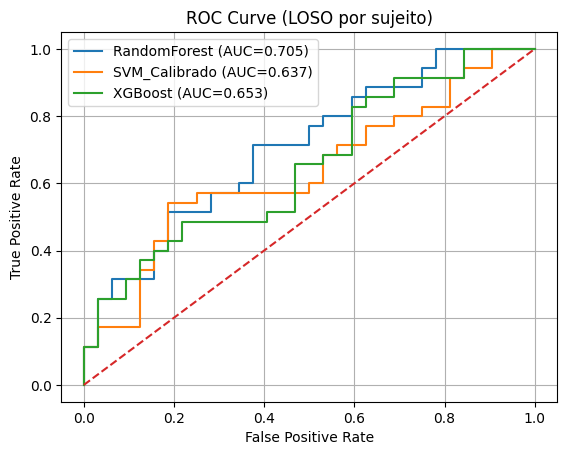

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure()

for nome, r in resultados_seguros.items():
    df = r['df_preds']
    
    fpr, tpr, _ = roc_curve(df['real'], df['proba'])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{nome} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')  # linha aleatória

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LOSO por sujeito)")
plt.legend()
plt.grid()

plt.show()

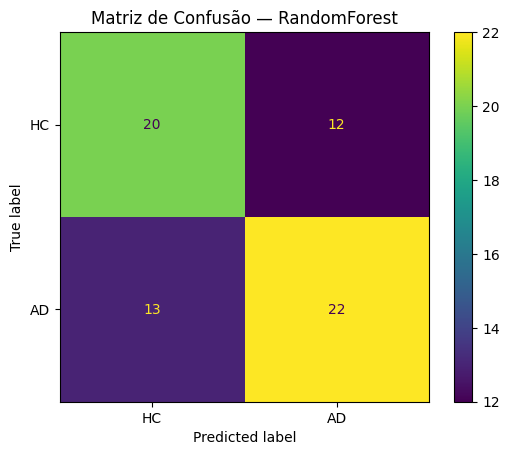

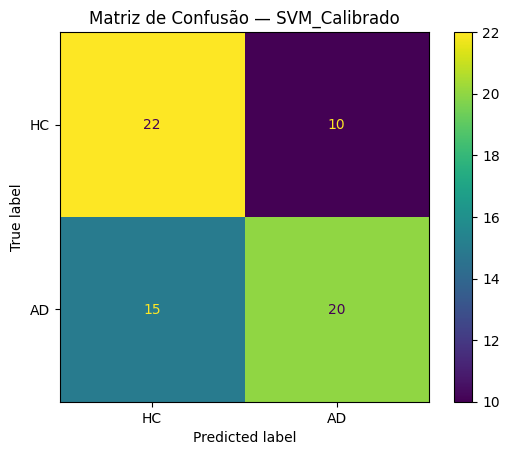

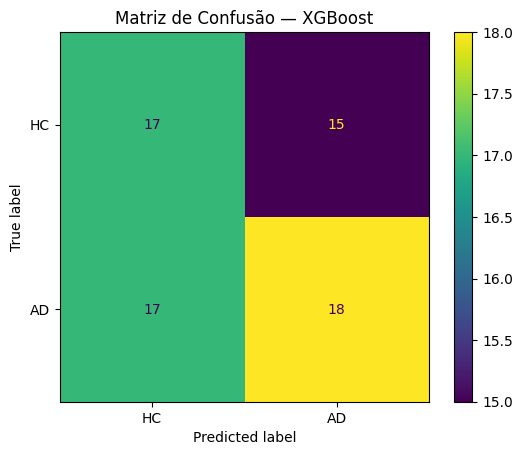

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for nome, r in resultados_seguros.items():
    df = r['df_preds']
    
    y_true = df['real']
    y_pred = (df['proba'] >= 0.5).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=["HC", "AD"])
    disp.plot()
    
    plt.title(f"Matriz de Confusão — {nome}")
    plt.show()

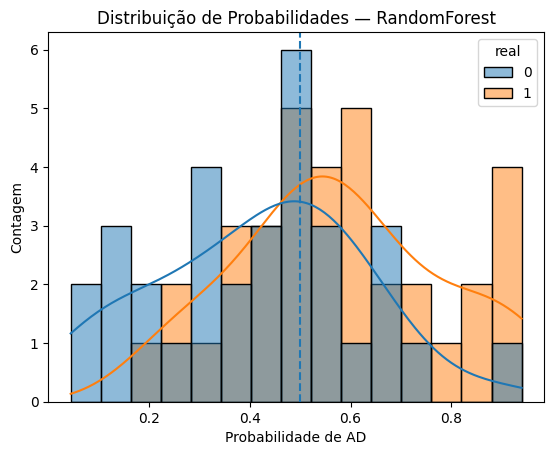

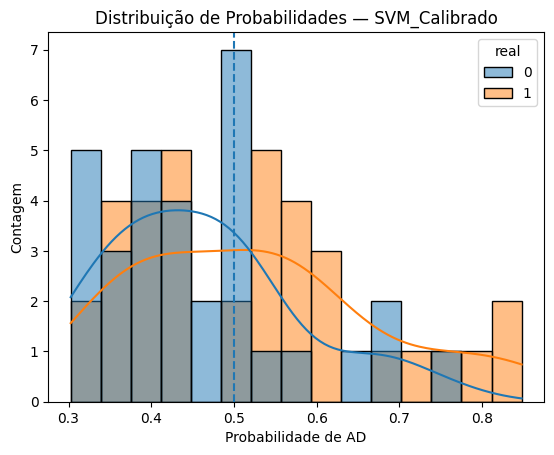

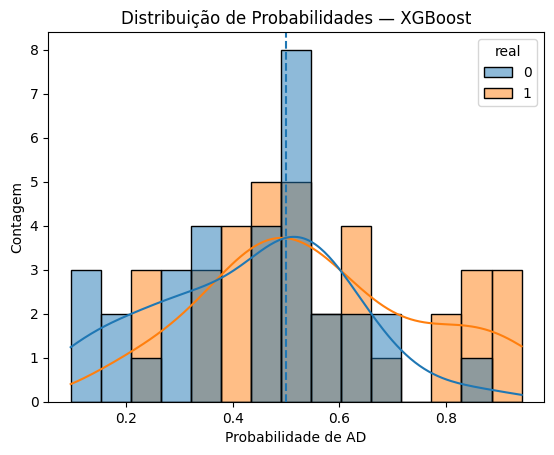

In [76]:
import seaborn as sns

for nome, r in resultados_seguros.items():
    df = r['df_preds']
    
    plt.figure()
    
    sns.histplot(data=df, x='proba', hue='real', bins=15, kde=True)
    
    plt.axvline(0.5, linestyle='--')  # threshold
    
    plt.title(f"Distribuição de Probabilidades — {nome}")
    plt.xlabel("Probabilidade de AD")
    plt.ylabel("Contagem")
    
    plt.show()

In [77]:
import pandas as pd

# ── Construção da tabela ─────────────────────────────
rows = []

for nome, r in resultados_seguros.items():
    rows.append({
        "Modelo": nome,
        "AUC": r['auc'],
        "Sensibilidade (Recall AD)": r['sens'],
        "Especificidade (Recall HC)": r['spec'],
    })

df_benchmark = pd.DataFrame(rows)

# Ordena por AUC (melhor primeiro)
df_benchmark = df_benchmark.sort_values(by="AUC", ascending=False)

# Reset index
df_benchmark = df_benchmark.reset_index(drop=True)

# Exibir
df_benchmark

,Modelo,AUC,Sensibilidade (Recall AD),Especificidade (Recall HC)
0,RandomForest,0.7054,0.6286,0.6250
1,XGBoost,0.6527,0.5143,0.5312
2,SVM_Calibrado,0.6366,0.5714,0.6875


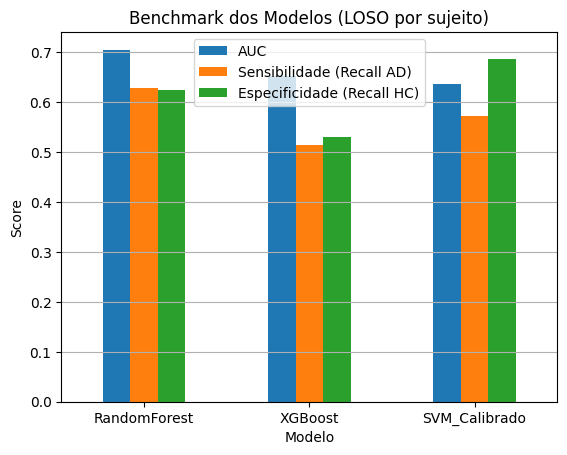

In [78]:
import matplotlib.pyplot as plt

df_plot = df_benchmark.set_index("Modelo")

df_plot.plot(kind="bar")

plt.title("Benchmark dos Modelos (LOSO por sujeito)")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

CÉLULA 6 — Permutation Test Agrupado (O Fim do P=1.0)

AD: s6_sub-30001_rs-hep_eeg.set -> RMS = 0.000007
AD: s6_sub-30002_rs-hep_eeg.set -> RMS = 0.000009
AD: s6_sub-30004_rs-hep_eeg.set -> RMS = 0.000003
AD: s6_sub-30008_rs-hep_eeg.set -> RMS = 0.000005
AD: s6_sub-30009_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30011_rs-hep_eeg.set -> RMS = 0.000005
AD: s6_sub-30012_rs-hep_eeg.set -> RMS = 0.000005
AD: s6_sub-30013_rs-hep_eeg.set -> RMS = 0.000005
AD: s6_sub-30015_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30017_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30018_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30020_rs-hep_eeg.set -> RMS = 0.000004
AD: s6_sub-30022_rs-hep_eeg.set -> RMS = 0.000004
AD: s6_sub-30026_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30029_rs-hep_eeg.set -> RMS = 0.000004
AD: s6_sub-30031_rs-hep_eeg.set -> RMS = 0.000004
AD: s6_sub-30003_rs-hep_eeg.set -> RMS = 0.000006
AD: s6_sub-30005_rs-hep_eeg.set -> RMS = 0.000009
AD: s6_sub-30006_rs-hep_eeg.set -> RMS = 0.000003
AD: s6_sub-30007_rs-hep_eeg.set -> RMS = 0.000008


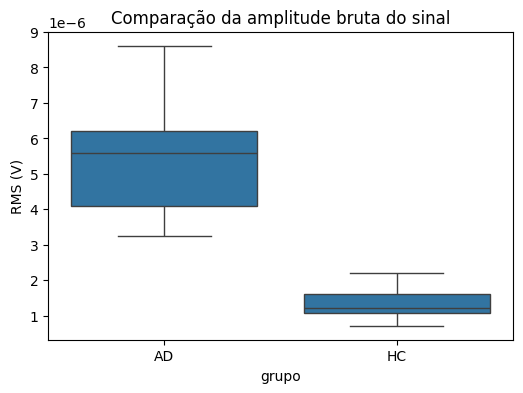

p-valor (Mann-Whitney): 0.000000


In [ ]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Função para calcular o RMS de um arquivo
def get_rms_from_file(file_path):
    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.set_eeg_reference('average', projection=False)
    raw.filter(0.5, 45, fir_design='firwin', verbose=False)
    data = raw.get_data()
    rms = np.sqrt(np.mean(data**2))
    return rms

# Coletar RMS de uma amostra de arquivos de cada grupo
rms_data = []
for grupo, pasta in [('AD', PASTA_AD), ('HC', PASTA_HC)]:
    arquivos = list(Path(pasta).rglob('*.set'))[:20]  # use 20 arquivos por grupo (ajuste)
    for arq in arquivos:
        try:
            rms = get_rms_from_file(arq)
            rms_data.append({'grupo': grupo, 'rms': rms, 'arquivo': arq.name})
            print(f"{grupo}: {arq.name} -> RMS = {rms:.6f}")
        except Exception as e:
            print(f"Erro em {arq.name}: {e}")

df_rms = pd.DataFrame(rms_data)

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(data=df_rms, x='grupo', y='rms')
plt.ylabel('RMS (V)')
plt.title('Comparação da amplitude bruta do sinal')
plt.show()

# Teste estatístico
stat, p = mannwhitneyu(df_rms[df_rms['grupo']=='AD']['rms'], 
                       df_rms[df_rms['grupo']=='HC']['rms'])
print(f"p-valor (Mann-Whitney): {p:.6f}")